# Analyse statistique du corpus `documents_all.jsonl`

Ce notebook propose une **exploration statistique complète** du corpus :
- structure du fichier JSONL ;
- contrôle de qualité des champs ;
- statistiques globales sur les documents ;
- distributions par **source**, **domaine**, **type de contenu** et **collection** ;
- statistiques lexicales : nombre de mots, vocabulaire, mots fréquents, bigrammes ;
- visualisations simples pour mieux comprendre le corpus.

Le notebook est pensé dans un style proche d'un **TP de TAL**, avec des cellules séparées par thèmes et un code facile à modifier.


## 1. Importation des bibliothèques

On utilise uniquement des bibliothèques classiques de l'écosystème Python scientifique :
- `json`, `re`, `collections`, `pathlib` pour le traitement du corpus ;
- `pandas` pour structurer les données ;
- `matplotlib` pour les graphiques.


In [1]:
import json
import math
import re
from collections import Counter
from pathlib import Path
from urllib.parse import urlparse

from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Chargement du corpus

Le notebook essaie plusieurs chemins possibles.  
Si besoin, modifie simplement la variable `JSONL_PATH` ci-dessous.


In [2]:
JSONL_PATH = "data/documents_all.jsonl"  

In [3]:
def load_jsonl(path):
    rows = []
    with open(path, 'r', encoding="utf-8") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"[WARN] Ligne {line_num} ignorée : {e}")
    return rows

rows = load_jsonl(JSONL_PATH)
print(f"Nombre total de lignes JSON chargées : {len(rows)}")
rows[:2]


Nombre total de lignes JSON chargées : 207


[{'doc_id': 'web_0000',
  'source': 'site',
  'title': 'CORIA-TALN 2025',
  'url': 'https://coria-taln-2025.lis-lab.fr/',
  'text': 'Accueil\nPrésentation\nOrganisée par l’Université d’Aix-Marseille et les UMR CNRS LIS et LPL, sous l’égide de l’Association francophone de Recherche d’Information et Applications (ARIA) et l’Association pour le Traitement Automatique des Langues (ATALA), l’édition 2025 regroupe :\n- La 20e Conférence en Recherche d’Information et Applications (CORIA)\n- Les 18e Rencontres Jeunes Chercheurs en RI (RJCRI)\n- La 32e Conférence sur le Traitement Automatique des Langues Naturelles (TALN)\n- La 27e Rencontre des Étudiants Chercheurs en Informatique pour le Traitement Automatique des Langues (RÉCITAL)\nCes événements auront lieu du 30 juin au 4 juillet 2025, à Marseille.\nLocalisation\nLa conférence se tiendra à Marseille, sur le campus de Saint-Charles.\nPour plus de détails sur le site, consultez la page Informations pratiques\nPour le programme détaillé : Pro

## 3. Mise en DataFrame et enrichissement

On transforme les lignes JSON en tableau `pandas`, puis on ajoute des colonnes utiles :
- longueur des textes en caractères, mots et lignes ;
- domaine de l'URL ;
- extension du fichier (`.pdf` ou page HTML) ;
- type de contenu détecté ;
- profondeur de l'URL ;
- collection extraite à partir du chemin.


In [4]:
df = pd.DataFrame(rows)

def safe_metadata_get(meta, key, default=None):
    if isinstance(meta, dict):
        return meta.get(key, default)
    return default

def word_count(text):
    if not isinstance(text, str):
        return 0
    return len(re.findall(r"\b\w+\b", text, flags=re.UNICODE))

def line_count(text):
    if not isinstance(text, str) or not text:
        return 0
    return text.count("\n") + 1

def get_domain(url):
    if not isinstance(url, str) or not url:
        return ""
    return urlparse(url).netloc

def get_path(url):
    if not isinstance(url, str) or not url:
        return ""
    return urlparse(url).path

def get_extension(url):
    path = get_path(url)
    m = re.search(r"(\.[A-Za-z0-9]+)$", path)
    if m:
        return m.group(1).lower()
    return "(none)"

def infer_content_type(row):
    meta_type = safe_metadata_get(row.get("metadata"), "content_type")
    if isinstance(meta_type, str) and meta_type.strip():
        return meta_type.strip().lower()
    ext = row.get("file_extension", "")
    if ext == ".pdf":
        return "pdf"
    return "unknown"

def url_depth(url):
    path = get_path(url).strip("/")
    if not path:
        return 0
    return len([part for part in path.split("/") if part])

def extract_collection(url):
    path = get_path(url).strip("/")
    if not path:
        return "(root)"
    parts = [p for p in path.split("/") if p]
    if len(parts) >= 2 and parts[0] in {"TALN", "RECITAL", "ateliers"}:
        return "/".join(parts[:2])
    return parts[0]

df["domain"] = df["url"].apply(get_domain)
df["path"] = df["url"].apply(get_path)
df["file_extension"] = df["url"].apply(get_extension)
df["content_type"] = df.apply(infer_content_type, axis=1)
df["url_depth"] = df["url"].apply(url_depth)

df["text"] = df["text"].fillna("")
df["title"] = df["title"].fillna("")
df["source"] = df["source"].fillna("unknown")

df["text_len_chars"] = df["text"].str.len()
df["word_count"] = df["text"].apply(word_count)
df["line_count"] = df["text"].apply(line_count)
df["title_len_chars"] = df["title"].str.len()
df["collection"] = df["url"].apply(extract_collection)

selected_columns = [
    "doc_id", "source", "title", "url", "domain",
    "file_extension", "content_type", "collection",
    "text_len_chars", "word_count", "line_count"
]
df[selected_columns].head()


,doc_id,source,title,url,domain,file_extension,content_type,collection,text_len_chars,word_count,line_count
0,web_0000,site,CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/,coria-taln-2025.lis-lab.fr,(none),html,(root),907,136,13
1,web_0001,site,Dates – CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/dates,coria-taln-2025.lis-lab.fr,(none),html,dates,365,55,6
2,web_0002,site,Ateliers – CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/ateliers,coria-taln-2025.lis-lab.fr,(none),html,ateliers,2646,412,29
3,web_0003,site,CORIA – CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/coria,coria-taln-2025.lis-lab.fr,(none),html,coria,5630,813,38
4,web_0004,site,TALN – CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/taln,coria-taln-2025.lis-lab.fr,(none),html,taln,4280,648,81


## 4. Contrôle de qualité du corpus

Cette section vérifie :
- la présence des champs importants ;
- les valeurs manquantes ;
- les éventuels doublons d'URL ou d'identifiants.


In [5]:
quality_stats = {
    "nb_documents": len(df),
    "doc_id_manquants": int((df["doc_id"].astype(str).str.strip() == "").sum()),
    "title_manquants": int((df["title"].astype(str).str.strip() == "").sum()),
    "url_manquantes": int((df["url"].astype(str).str.strip() == "").sum()),
    "textes_vides": int((df["text"].astype(str).str.strip() == "").sum()),
    "urls_dupliquees": int(df["url"].duplicated().sum()),
    "doc_id_dupliques": int(df["doc_id"].duplicated().sum()),
    "titres_dupliques": int(df["title"].duplicated().sum()),
}

pd.DataFrame(
    [{"Mesure": key, "Valeur": value} for key, value in quality_stats.items()]
)


,Mesure,Valeur
0,nb_documents,207
1,doc_id_manquants,0
2,title_manquants,0
3,url_manquantes,0
4,textes_vides,0
5,urls_dupliquees,0
6,doc_id_dupliques,0
7,titres_dupliques,0


In [6]:
print("Répartition des documents par source :")
display(df["source"].value_counts().rename_axis("source").reset_index(name="nb_documents"))

print("\nRépartition des types de contenu détectés :")
display(df["content_type"].value_counts().rename_axis("content_type").reset_index(name="nb_documents"))

print("\nRépartition des extensions de fichiers :")
display(df["file_extension"].value_counts().rename_axis("extension").reset_index(name="nb_documents"))


Répartition des documents par source :


,source,nb_documents
0,article,104
1,article_bib_only,80
2,site,23



Répartition des types de contenu détectés :


,content_type,nb_documents
0,pdf,184
1,html,23



Répartition des extensions de fichiers :


,extension,nb_documents
0,.pdf,184
1,(none),23


## 5. Statistiques globales de longueur

On mesure la taille des documents :
- en caractères ;
- en mots ;
- en lignes.


In [7]:
global_stats = pd.DataFrame({
    "text_len_chars": df["text_len_chars"].describe(),
    "word_count": df["word_count"].describe(),
    "line_count": df["line_count"].describe(),
    "title_len_chars": df["title_len_chars"].describe(),
}).round(2)

global_stats


,text_len_chars,word_count,line_count,title_len_chars
count,207.00,207.00,207.00,207.00
mean,20642.89,3361.08,434.93,99.78
std,27268.33,4554.09,951.31,39.35
min,250.00,31.00,1.00,15.00
25%,1590.00,251.00,5.00,73.50
50%,4302.00,648.00,46.00,102.00
75%,41146.50,6362.00,675.50,127.00
max,188200.00,27203.00,9445.00,194.00


In [8]:
stats_by_source = (
    df.groupby("source")[["text_len_chars", "word_count", "line_count"]]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

stats_by_source
#Enlever article avec tout les articles car tres long et revient a chaque rag

text_len_chars                                  word_count  \
                          count      mean   median   min     max      count   
source                                                                        
article                     104  37384.21  40584.5  3119  133615        104   
article_bib_only             80   1515.81   1552.0   523    2409         80   
site                         23  11471.96   2747.0   250  188200         23   

                                              line_count                     \
                     mean  median  min    max      count    mean median min   
source                                                                        
article           6136.32  6309.5  484  26201        104  845.33  674.0  40   
article_bib_only   239.18   247.5   81    391         80    4.99    5.0   4   
site              1670.96   476.0   31  27203         23   74.65   29.0   1   

                        
                   max  
source                  
article           9445  
article_bib_only     5  
site               922

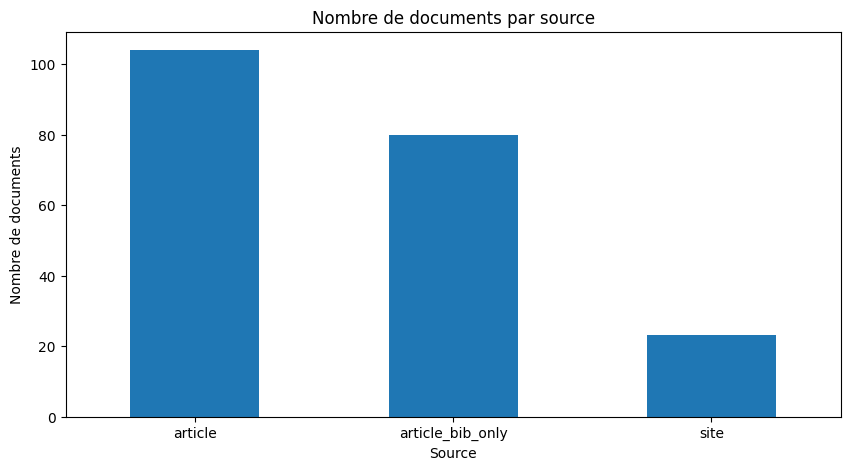

In [9]:
fig, ax = plt.subplots()
df["source"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Nombre de documents par source")
ax.set_xlabel("Source")
ax.set_ylabel("Nombre de documents")
plt.xticks(rotation=0)
plt.show()


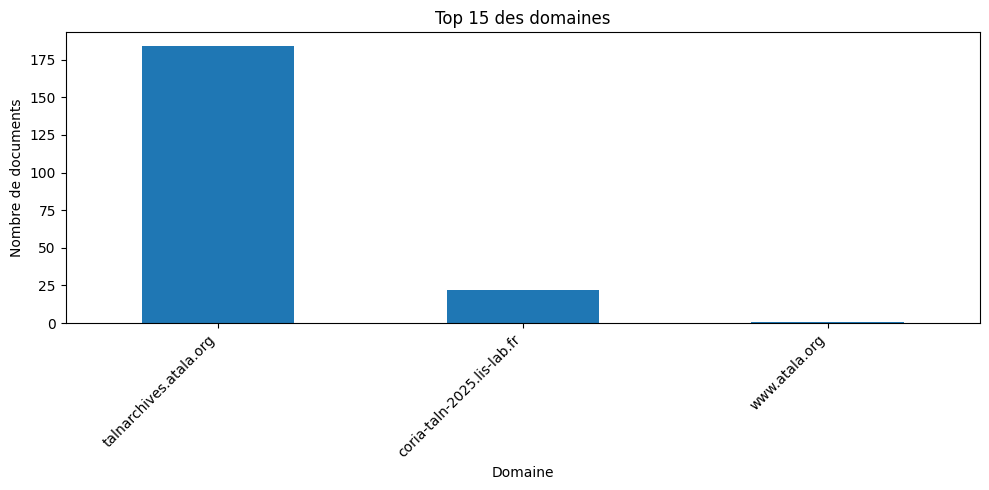

In [10]:
fig, ax = plt.subplots()
df["domain"].value_counts().head(15).plot(kind="bar", ax=ax)
ax.set_title("Top 15 des domaines")
ax.set_xlabel("Domaine")
ax.set_ylabel("Nombre de documents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


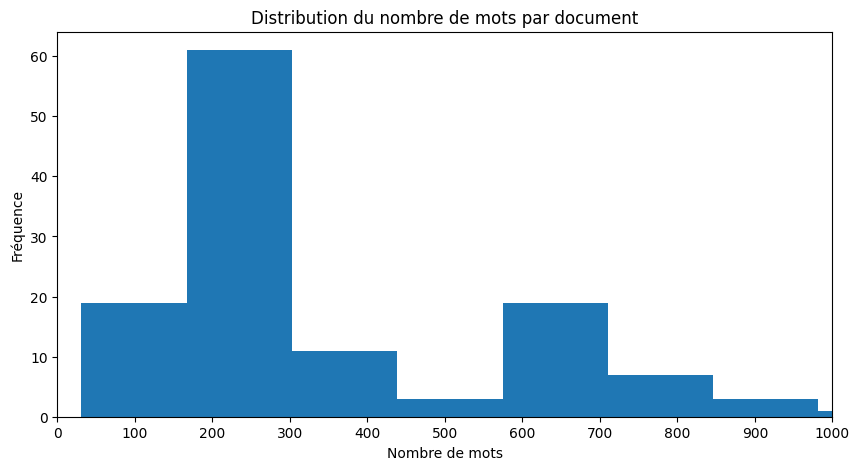

<Figure size 4000x1500 with 0 Axes>

In [11]:
from matplotlib.ticker import MultipleLocator
fig, ax = plt.subplots()
plt.figure(figsize=(40, 15))
df["word_count"].plot(kind="hist", bins=200, ax=ax)
ax.set_xlim(0, 1000)
ax.set_title("Distribution du nombre de mots par document")
ax.set_xlabel("Nombre de mots")
ax.set_ylabel("Fréquence")
ax.xaxis.set_major_locator(MultipleLocator(100))  # un trait tous les 500
ax.yaxis.set_major_locator(MultipleLocator(10)) 
plt.show()



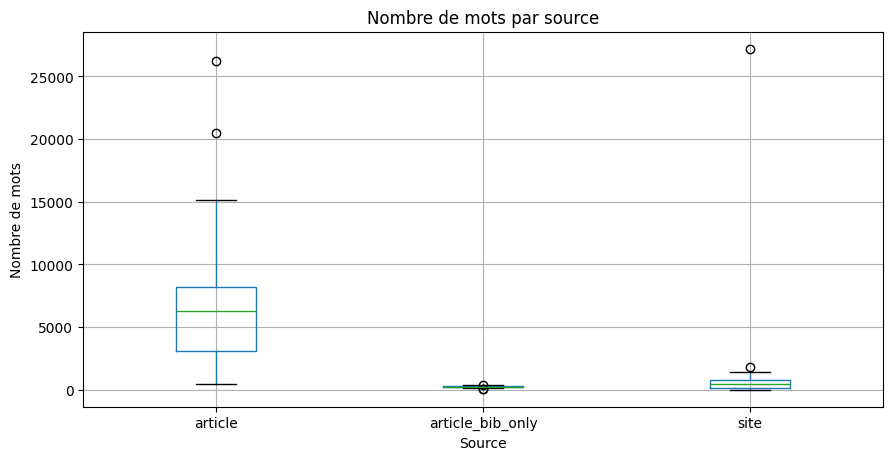

In [31]:
fig, ax = plt.subplots()
df.boxplot(column="word_count", by="source", ax=ax)
ax.set_title("Nombre de mots par source")
ax.set_xlabel("Source")
ax.set_ylabel("Nombre de mots")
plt.suptitle("")
plt.show()


## 6. Les documents les plus courts et les plus longs

Cela permet d'identifier rapidement :
- les documents très riches ;
- les entrées bibliographiques très courtes ;
- d'éventuels cas extrêmes.


In [13]:
print("10 documents les plus longs (en mots) :")
display(
    df.sort_values("word_count", ascending=False)[
        ["doc_id", "source", "title", "url", "word_count", "text_len_chars"]
    ].head(10)
)

print("\n10 documents les plus courts (en mots) :")
display(
    df.sort_values("word_count", ascending=True)[
        ["doc_id", "source", "title", "url", "word_count", "text_len_chars"]
    ].head(10)
)


10 documents les plus longs (en mots) :


,doc_id,source,title,url,word_count,text_len_chars
9,web_0009,site,Programme détaillé – CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/programme-detaille,27203,188200
44,article_0021,article,La traduction automatique dialectale: \'etat de l'art et \'etude pr\'eliminaire sur le continuum dialectal de l'occitan,https://talnarchives.atala.org/RECITAL/RECITAL-2025/130.pdf,26201,133615
39,article_0016,article,ALF : Un jeu de donn\'ees d'analogies fran\ccaises \`a grain fin pour l'\'evaluation de la connaissance lexicale des...,https://talnarchives.atala.org/TALN/TALN-2025/12.pdf,20492,94133
38,article_0015,article,Connaissances factuelles dans les mod\`eles de langue : robustesse et anomalies face \`a des variations simples du c...,https://talnarchives.atala.org/TALN/TALN-2025/119.pdf,15156,87552
120,article_0097,article,MOSAIC : M\'elange d'experts pour la d\'etection de textes artificiels,https://talnarchives.atala.org/TALN/TALN-2025/87.pdf,13880,74669
47,article_0024,article,\'Evaluer la capacit\'e des transformeurs \`a distinguer les significations compositionnelles et idiomatiques d'une ...,https://talnarchives.atala.org/TALN/TALN-2025/133.pdf,12974,60451
86,article_0063,article,Identification de mesures d'\'evaluation fiables pour la r\'evision de textes scientifiques,https://talnarchives.atala.org/TALN/TALN-2025/38.pdf,12672,74352
23,article_0000,article,Une revue sur les hallucinations des LLM,https://talnarchives.atala.org/TALN/TALN-2025/10.pdf,12432,78520
111,article_0088,article,QUARTZ : Approche abstractive non supervis\'ee par question-r\'eponse pour le r\'esum\'e de dialogue orient\'e t\^ache,https://talnarchives.atala.org/TALN/TALN-2025/77.pdf,11445,69870
118,article_0095,article,\'Etat de l'art sur les marqueurs discursifs en Traitement Automatique des Langues,https://talnarchives.atala.org/RECITAL/RECITAL-2025/83.pdf,11090,70915



10 documents les plus courts (en mots) :


,doc_id,source,title,url,word_count,text_len_chars
16,web_0016,site,Sponsors – CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/sponsors,31,250
12,web_0012,site,Actes en ligne – CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/actes-en-ligne,49,315
1,web_0001,site,Dates – CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/dates,55,365
153,bib_0026,article_bib_only,La science participative et l'ANR DiLSi,https://talnarchives.atala.org/ateliers/2025/ParCol/185.pdf,81,523
17,web_0017,site,Comité d’organisation – CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/comite-dorganisation,83,662
7,web_0007,site,Soumission – CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/feuilles-de-style,86,559
182,bib_0055,article_bib_only,''POPCORN-RENS : un nouveau jeu de donn\'ees en fran\ccais annot\'e en entit\'es d'int\'er\^ets sur une th\'ematique...,https://talnarchives.atala.org/ateliers/2025/EvalLLM/638877.pdf,95,571
172,bib_0045,article_bib_only,Analyse exploratoire des traces num\'eriques clavier pour la pr\'ediction des niveaux d\textquoterightapprenants,https://talnarchives.atala.org/ateliers/2025/DYN-TAL/218.pdf,120,814
20,web_0020,site,Comité de programme RJC (RECITAL-RJCRI) – CORIA-TALN 2025,https://coria-taln-2025.lis-lab.fr/comite-de-programme-rjc-recital-rjcri,122,956
151,bib_0024,article_bib_only,Une approche hybride de l'IA pour les technologies \'educatives : augmenter les STI avec l'IA g\'en\'erative,https://talnarchives.atala.org/ateliers/2025/IA-ÉDU/182.pdf,126,808


## 7. Collections et structure des URLs

Ici, on regroupe les documents par familles de chemins :
- `TALN/TALN-2025`
- `RECITAL/RECITAL-2025`
- `ateliers/2025`
- pages du site de conférence.


In [14]:
collection_counts = df["collection"].value_counts().rename_axis("collection").reset_index(name="nb_documents")
collection_counts.head(20)


,collection,nb_documents
0,TALN/TALN-2025,105
1,ateliers/2025,63
2,RECITAL/RECITAL-2025,16
3,(root),2
4,dates,1
5,ateliers,1
6,coria,1
7,taln,1
8,rjc-recital-rjcri,1
9,session-industrielle,1


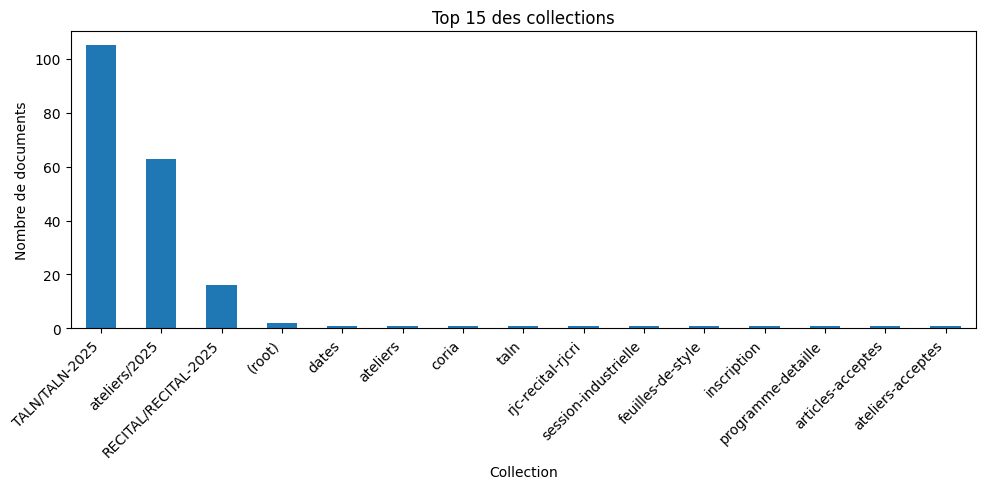

In [15]:
fig, ax = plt.subplots()
df["collection"].value_counts().head(15).plot(kind="bar", ax=ax)
ax.set_title("Top 15 des collections")
ax.set_xlabel("Collection")
ax.set_ylabel("Nombre de documents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [16]:
url_depth_stats = df["url_depth"].describe().round(2)
url_depth_stats


count    207.00
mean       3.07
std        0.89
min        0.00
25%        3.00
50%        3.00
75%        4.00
max        4.00
Name: url_depth, dtype: float64

## 8. Analyse lexicale

On réalise maintenant une analyse simple du texte :
- tokenisation légère par expression régulière ;
- suppression d'une petite liste de stopwords ;
- calcul du vocabulaire global ;
- fréquence des mots et des bigrammes.


In [17]:
FRENCH_STOPWORDS = {
    "de", "la", "le", "les", "des", "du", "un", "une", "et", "en", "a", "à", "au", "aux",
    "pour", "par", "sur", "dans", "qui", "que", "qu", "est", "sont", "être", "avec", "plus",
    "ou", "où", "ce", "ces", "cet", "cette", "il", "elle", "ils", "elles", "nous", "vous",
    "je", "tu", "se", "sa", "son", "ses", "leur", "leurs", "ne", "pas", "mais", "donc",
    "car", "ni", "or", "si", "comme", "afin", "entre", "ainsi", "été", "ont", "dans", "pour",
    "the", "of", "and", "to", "for", "with", "from", "this", "that", "these", "those",
    "d", "l", "n", "m", "s", "c", "y"
}

def tokenize(text):
    if not isinstance(text, str):
        return []
    return re.findall(r"[A-Za-zÀ-ÿ0-9\-']+", text.lower(), flags=re.UNICODE)

def normalize_tokens(tokens):
    cleaned = []
    for tok in tokens:
        tok = tok.strip("-'")
        if len(tok) < 3:
            continue
        if tok.isdigit():
            continue
        if tok in FRENCH_STOPWORDS:
            continue
        cleaned.append(tok)
    return cleaned

df["tokens"] = df["text"].apply(lambda x: normalize_tokens(tokenize(x)))
df["token_count_filtered"] = df["tokens"].apply(len)
df["unique_token_count"] = df["tokens"].apply(lambda toks: len(set(toks)))

all_tokens = [tok for toks in df["tokens"] for tok in toks]
vocab_counter = Counter(all_tokens)
vocab_size = len(vocab_counter)
hapax_count = sum(1 for _, c in vocab_counter.items() if c == 1)

lexical_summary = pd.DataFrame([
    {"Mesure": "Nombre total de tokens filtrés", "Valeur": len(all_tokens)},
    {"Mesure": "Taille du vocabulaire", "Valeur": vocab_size},
    {"Mesure": "Nombre d'hapax (fréquence = 1)", "Valeur": hapax_count},
    {"Mesure": "Proportion d'hapax", "Valeur": round(hapax_count / vocab_size, 4) if vocab_size else 0},
    {"Mesure": "Moyenne de tokens filtrés par document", "Valeur": round(df["token_count_filtered"].mean(), 2)},
    {"Mesure": "Moyenne de tokens uniques par document", "Valeur": round(df["unique_token_count"].mean(), 2)},
])

lexical_summary


,Mesure,Valeur
0,Nombre total de tokens filtrés,354118.0000
1,Taille du vocabulaire,37022.0000
2,Nombre d'hapax (fréquence = 1),16111.0000
3,Proportion d'hapax,0.4352
4,Moyenne de tokens filtrés par document,1710.7100
5,Moyenne de tokens uniques par document,740.7800


In [18]:
top_words = pd.DataFrame(vocab_counter.most_common(25), columns=["mot", "frequence"])
top_words


,mot,frequence
0,corpus,2016
1,modèles,1853
2,modèle,1647
3,données,1622
4,language,1401
5,computational,1047
6,association,1043
7,linguistics,1020
8,doi,994
9,deux,928


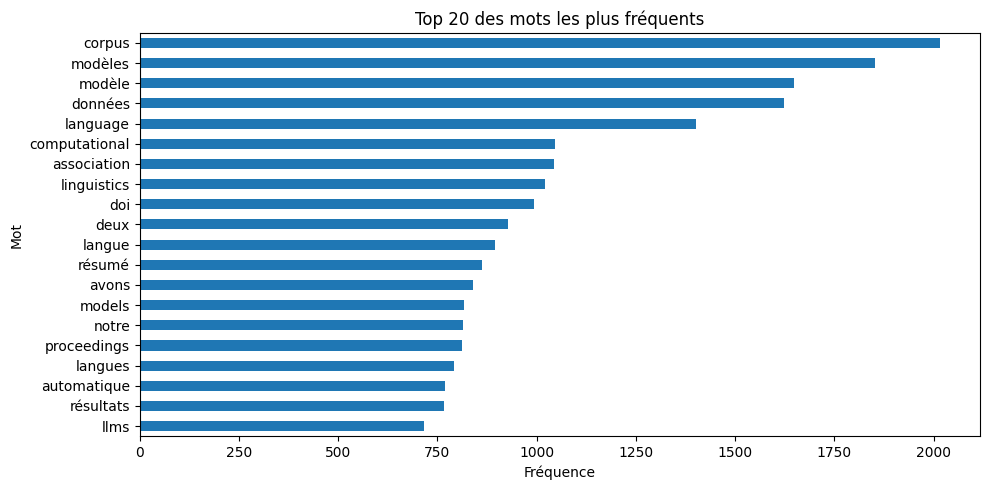

In [19]:
fig, ax = plt.subplots()
top_words.iloc[:20].sort_values("frequence").plot(kind="barh", x="mot", y="frequence", legend=False, ax=ax)
ax.set_title("Top 20 des mots les plus fréquents")
ax.set_xlabel("Fréquence")
ax.set_ylabel("Mot")
plt.tight_layout()
plt.show()


In [20]:
bigram_counter = Counter()
for toks in df["tokens"]:
    for a, b in zip(toks, toks[1:]):
        bigram_counter[(a, b)] += 1

top_bigrams = pd.DataFrame(
    [(f"{a} {b}", freq) for (a, b), freq in bigram_counter.most_common(20)],
    columns=["bigramme", "frequence"]
)

top_bigrams


,bigramme,frequence
0,computational linguistics,957
1,association computational,864
2,language models,474
3,éds proceedings,448
4,linguistics doi,435
5,mod eles,320
6,natural language,317
7,large language,304
8,traitement automatique,299
9,modèles langue,270


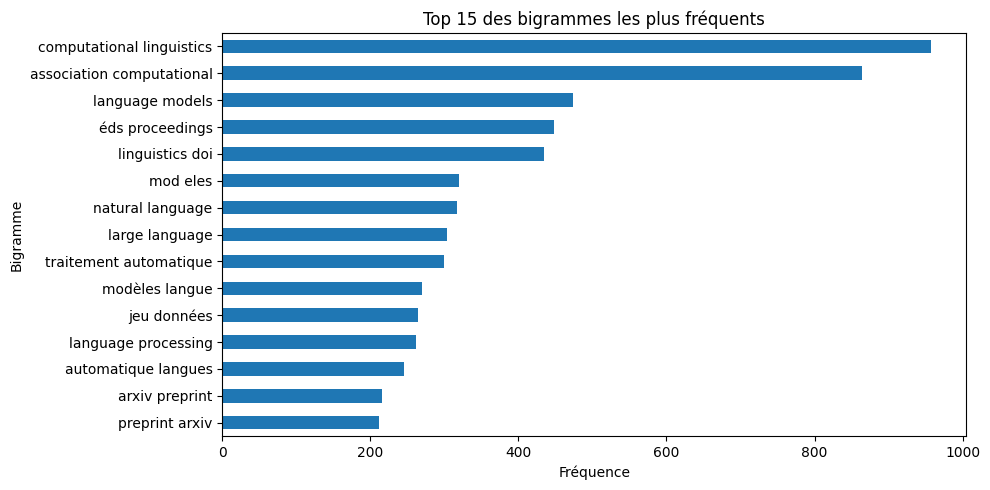

In [21]:
fig, ax = plt.subplots()
top_bigrams.iloc[:15].sort_values("frequence").plot(kind="barh", x="bigramme", y="frequence", legend=False, ax=ax)
ax.set_title("Top 15 des bigrammes les plus fréquents")
ax.set_xlabel("Fréquence")
ax.set_ylabel("Bigramme")
plt.tight_layout()
plt.show()


## 9. Analyse lexicale par source

On compare ici les familles de documents :
- `site`
- `article`
- `article_bib_only`


In [22]:
lexical_by_source = (
    df.groupby("source")[["word_count", "token_count_filtered", "unique_token_count"]]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

lexical_by_source


word_count                              token_count_filtered  \
                      count     mean  median  min    max                count   
source                                                                          
article                 104  6136.32  6309.5  484  26201                  104   
article_bib_only         80   239.18   247.5   81    391                   80   
site                     23  1670.96   476.0   31  27203                   23   

                                              unique_token_count           \
                     mean  median  min    max              count     mean   
source                                                                      
article           3077.48  3367.5  290   9598                104  1309.14   
article_bib_only   131.30   134.0   47    213                 80    99.60   
site              1024.17   256.0   22  16825                 23   400.96   

                                     
                  median  min   max  
source                               
article           1486.5  175  2776  
article_bib_only   102.0   39   151  
site               175.0   15  4630

In [23]:
source_vocab = {}
for source_name, subdf in df.groupby("source"):
    tokens = [tok for toks in subdf["tokens"] for tok in toks]
    source_vocab[source_name] = Counter(tokens).most_common(15)

for source_name, common_words in source_vocab.items():
    print("=" * 80)
    print(f"Source : {source_name}")
    display(pd.DataFrame(common_words, columns=["mot", "frequence"]))


Source : article


,mot,frequence
0,corpus,1856
1,modèle,1571
2,modèles,1567
3,données,1463
4,language,1375
5,computational,1046
6,association,1036
7,linguistics,1020
8,doi,994
9,deux,867


Source : article_bib_only


,mot,frequence
0,textquoteright,221
1,ees,182
2,mod,169
3,actes,160
4,eles,141
5,evaluation,99
6,recherche,95
7,donn,94
8,titre,80
9,auteurs,80


Source : site


,mot,frequence
0,résumé,310
1,modèles,286
2,papier,261
3,taln,187
4,langue,161
5,données,159
6,session,154
7,mots,144
8,pdf,137
9,corpus,130


## 10. Repérage de quelques artefacts textuels

Comme le corpus mélange pages web et textes issus de PDF, on peut observer certains artefacts :
- séquences LaTeX ou d'échappement (`\`, `\textquoteright`) ;
- apostrophes et accents encodés de façon irrégulière ;
- vocabulaire bibliographique très fréquent (`doi`, `proceedings`, etc.).

Ces indicateurs peuvent être utiles avant un prétraitement ou un chunking.


In [24]:
artifact_patterns = {
    "contient_un_backslash": df["text"].str.contains(r"\\", regex=True, na=False),
    "contient_textquoteright": df["text"].str.contains(r"textquoteright", regex=True, na=False),
    "contient_arxiv": df["text"].str.contains(r"arxiv", case=False, regex=True, na=False),
    "contient_doi": df["text"].str.contains(r"\bdoi\b", case=False, regex=True, na=False),
}

artifact_stats = pd.DataFrame([
    {"Mesure": name, "Nb documents": int(mask.sum()), "Proportion": round(mask.mean(), 4)}
    for name, mask in artifact_patterns.items()
])

artifact_stats


,Mesure,Nb documents,Proportion
0,contient_un_backslash,185,0.8937
1,contient_textquoteright,80,0.3865
2,contient_arxiv,58,0.2802
3,contient_doi,73,0.3527


## 11. Quelques indicateurs supplémentaires

On ajoute ici quelques mesures utiles :
- corrélation entre longueur du titre et longueur du document ;
- proportion de documents PDF ;
- aperçu des documents avec le plus de lignes.


In [25]:
correlation = df[["title_len_chars", "word_count", "text_len_chars", "line_count"]].corr().round(3)
correlation


,title_len_chars,word_count,text_len_chars,line_count
title_len_chars,1.000,0.003,-0.013,0.085
word_count,0.003,1.000,0.991,0.788
text_len_chars,-0.013,0.991,1.000,0.704
line_count,0.085,0.788,0.704,1.000


In [26]:
pdf_ratio = (df["file_extension"] == ".pdf").mean()
html_ratio = (df["content_type"] == "html").mean()

extra_stats = pd.DataFrame([
    {"Mesure": "Proportion de PDF", "Valeur": round(pdf_ratio, 4)},
    {"Mesure": "Proportion de HTML", "Valeur": round(html_ratio, 4)},
    {"Mesure": "Nombre moyen de lignes par document", "Valeur": round(df["line_count"].mean(), 2)},
    {"Mesure": "Profondeur moyenne des URLs", "Valeur": round(df["url_depth"].mean(), 2)},
])

extra_stats


,Mesure,Valeur
0,Proportion de PDF,0.8889
1,Proportion de HTML,0.1111
2,Nombre moyen de lignes par document,434.9300
3,Profondeur moyenne des URLs,3.0700


In [27]:
print("Documents avec le plus de lignes :")
display(
    df.sort_values("line_count", ascending=False)[
        ["doc_id", "source", "title", "url", "line_count", "word_count"]
    ].head(10)
)


Documents avec le plus de lignes :


,doc_id,source,title,url,line_count,word_count
39,article_0016,article,ALF : Un jeu de donn\'ees d'analogies fran\ccaises \`a grain fin pour l'\'evaluation de la connaissance lexicale des...,https://talnarchives.atala.org/TALN/TALN-2025/12.pdf,9445,20492
44,article_0021,article,La traduction automatique dialectale: \'etat de l'art et \'etude pr\'eliminaire sur le continuum dialectal de l'occitan,https://talnarchives.atala.org/RECITAL/RECITAL-2025/130.pdf,6363,26201
47,article_0024,article,\'Evaluer la capacit\'e des transformeurs \`a distinguer les significations compositionnelles et idiomatiques d'une ...,https://talnarchives.atala.org/TALN/TALN-2025/133.pdf,4352,12974
120,article_0097,article,MOSAIC : M\'elange d'experts pour la d\'etection de textes artificiels,https://talnarchives.atala.org/TALN/TALN-2025/87.pdf,3067,13880
86,article_0063,article,Identification de mesures d'\'evaluation fiables pour la r\'evision de textes scientifiques,https://talnarchives.atala.org/TALN/TALN-2025/38.pdf,2830,12672
89,article_0066,article,Adaptation des connaissances m\'edicales pour les grands mod\`eles de langue : Strat\'egies et analyse comparative,https://talnarchives.atala.org/TALN/TALN-2025/42.pdf,2159,10340
38,article_0015,article,Connaissances factuelles dans les mod\`eles de langue : robustesse et anomalies face \`a des variations simples du c...,https://talnarchives.atala.org/TALN/TALN-2025/119.pdf,2096,15156
111,article_0088,article,QUARTZ : Approche abstractive non supervis\'ee par question-r\'eponse pour le r\'esum\'e de dialogue orient\'e t\^ache,https://talnarchives.atala.org/TALN/TALN-2025/77.pdf,1450,11445
41,article_0018,article,Am\'eliorer la Traduction Neuronale par Exemple avec des Donn\'ees Monolingues,https://talnarchives.atala.org/TALN/TALN-2025/126.pdf,1449,9751
75,article_0052,article,Comparaison des approches bas\'ees sur BERT et sur l'agent LLM pour la classification hi\'erarchique de narratifs da...,https://talnarchives.atala.org/RECITAL/RECITAL-2025/217.pdf,1407,8863


## 12. Conclusion

Ce notebook fournit une base solide pour :
- décrire le corpus dans un rapport ;
- comparer les sous-parties du jeu de données ;
- préparer un pipeline de recherche d'information ou de RAG ;
- identifier les choix de prétraitement les plus pertinents.

Idées d'extensions possibles :
1. faire un **chunking** et refaire les statistiques au niveau des chunks ;
2. comparer la distribution du vocabulaire avant et après normalisation ;
3. mesurer le taux de recouvrement lexical entre questions et documents ;
4. construire des graphes ou des nuages de mots par collection.
